#  Interseções - Trabalho × Outros Fatores
## Análise de Subgrupos e Interações

**Notebook 5/7** - Série: Trabalho Estudantil e Desempenho no ENEM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path('/home/interas/faculdade/ciencia-dados/enem-data-exploration')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'enem_2023_trabalho_estudantil.parquet'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'unidade-3'

df = pd.read_parquet(DATA_FILE)
print(f" Dados carregados: {len(df):,} registros")

 Dados carregados: 1,000 registros


## 1⃣ Trabalho × Renda Familiar

 NOTA MÉDIA: RENDA × TRABALHO
CATEGORIA_TRABALHO  Não trabalha  Período integral  Trabalho parcial
RENDA_CAT                                                           
Baixa                     450.93            534.48            518.71
Média                     718.98            563.57            587.06
Alta                      574.58            655.22            624.80


/tmp/ipykernel_13413/2860482442.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_renda = df.pivot_table(


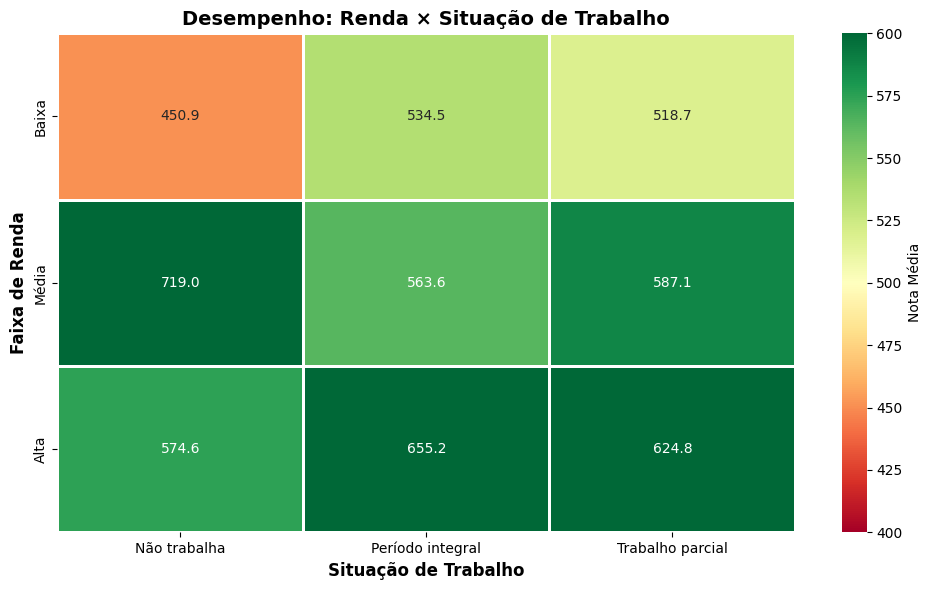


 GAP (Não trabalha - Período integral) POR RENDA:
  Baixa: -83.56 pontos
  Média: 155.41 pontos
  Alta: -80.64 pontos


In [2]:
if 'Q006_ord' in df.columns:
    # Criar categorias de renda simplificadas
    df['RENDA_CAT'] = pd.cut(df['Q006_ord'], bins=[0, 5, 10, 17], 
                             labels=['Baixa', 'Média', 'Alta'])
    
    # Tabela cruzada
    pivot_renda = df.pivot_table(
        values='NOTA_MEDIA_5',
        index='RENDA_CAT',
        columns='CATEGORIA_TRABALHO',
        aggfunc='mean'
    )
    
    print(" NOTA MÉDIA: RENDA × TRABALHO")
    print(pivot_renda.round(2))
    
    # Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_renda, annot=True, fmt='.1f', cmap='RdYlGn',
               vmin=400, vmax=600, cbar_kws={'label': 'Nota Média'},
               linewidths=2, linecolor='white')
    plt.title('Desempenho: Renda × Situação de Trabalho', fontsize=14, fontweight='bold')
    plt.xlabel('Situação de Trabalho', fontsize=12, fontweight='bold')
    plt.ylabel('Faixa de Renda', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '09_intersecao_renda_trabalho.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Análise do gap por renda
    print("\n GAP (Não trabalha - Período integral) POR RENDA:")
    for renda in ['Baixa', 'Média', 'Alta']:
        if 'Não trabalha' in pivot_renda.columns and 'Período integral' in pivot_renda.columns:
            gap = pivot_renda.loc[renda, 'Não trabalha'] - pivot_renda.loc[renda, 'Período integral']
            print(f"  {renda}: {gap:.2f} pontos")

## 2⃣ Trabalho × Tipo de Escola


 NOTA MÉDIA: ESCOLA × TRABALHO
CATEGORIA_TRABALHO  Não trabalha  Período integral  Trabalho parcial
ESCOLA_LABEL                                                        
Privada                   512.95            552.88            536.95
Pública                   499.46            533.82            523.86


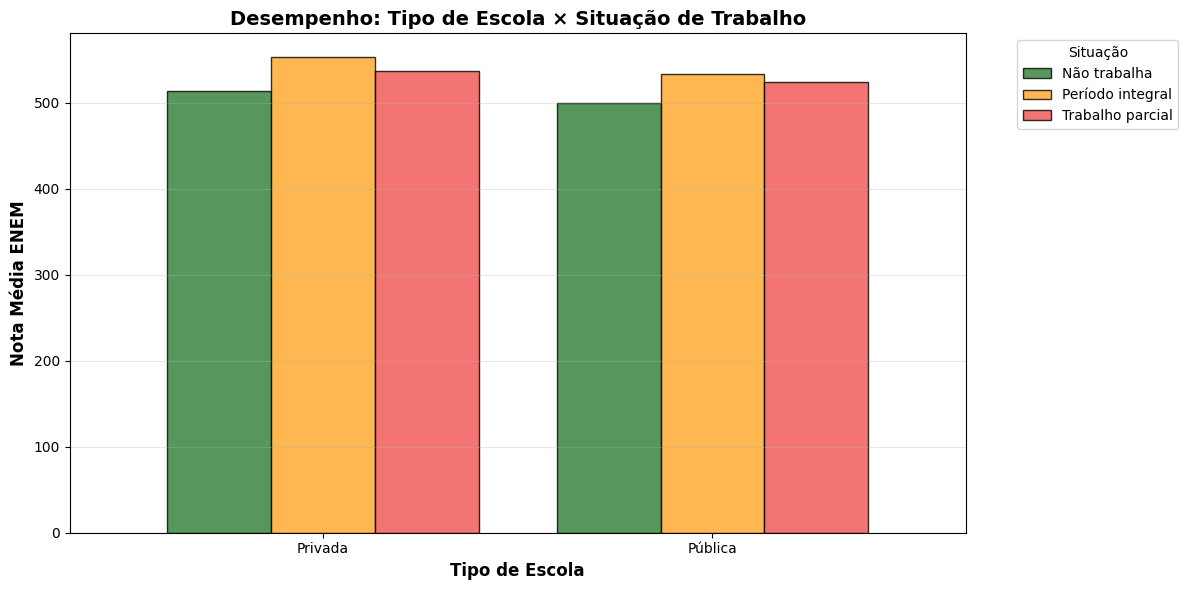


 GAP PÚBLICO-PRIVADA POR SITUAÇÃO DE TRABALHO:
  Não trabalha: 13.48 pontos
  Período integral: 19.06 pontos
  Trabalho parcial: 13.09 pontos


In [3]:
if 'TP_ESCOLA' in df.columns:
    escola_map = {1: 'Privada', 2: 'Pública'}
    df['ESCOLA_LABEL'] = df['TP_ESCOLA'].map(escola_map)
    
    pivot_escola = df.pivot_table(
        values='NOTA_MEDIA_5',
        index='ESCOLA_LABEL',
        columns='CATEGORIA_TRABALHO',
        aggfunc='mean'
    )
    
    print("\n NOTA MÉDIA: ESCOLA × TRABALHO")
    print(pivot_escola.round(2))
    
    # Gráfico de barras agrupadas
    pivot_escola.plot(kind='bar', figsize=(12, 6), 
                     color=['#2E7D32', '#FFA726', '#EF5350'],
                     alpha=0.8, edgecolor='black', width=0.8)
    plt.xlabel('Tipo de Escola', fontsize=12, fontweight='bold')
    plt.ylabel('Nota Média ENEM', fontsize=12, fontweight='bold')
    plt.title('Desempenho: Tipo de Escola × Situação de Trabalho', 
             fontsize=14, fontweight='bold')
    plt.xticks(rotation=0)
    plt.legend(title='Situação', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '10_intersecao_escola_trabalho.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Gap Escola
    print("\n GAP PÚBLICO-PRIVADA POR SITUAÇÃO DE TRABALHO:")
    for col in pivot_escola.columns:
        gap = pivot_escola.loc['Privada', col] - pivot_escola.loc['Pública', col]
        print(f"  {col}: {gap:.2f} pontos")

## 3⃣ Trabalho × Região


 NOTA MÉDIA: REGIÃO × TRABALHO
CATEGORIA_TRABALHO  Não trabalha  Período integral  Trabalho parcial
REGIAO_NOME_PROVA                                                   
Centro-Oeste              680.90            457.65            532.40
Nordeste                  395.57            571.77            522.75
Norte                     528.36            531.41            503.31
Sudeste                   552.78            565.81            567.39
Sul                          NaN            554.33            557.11


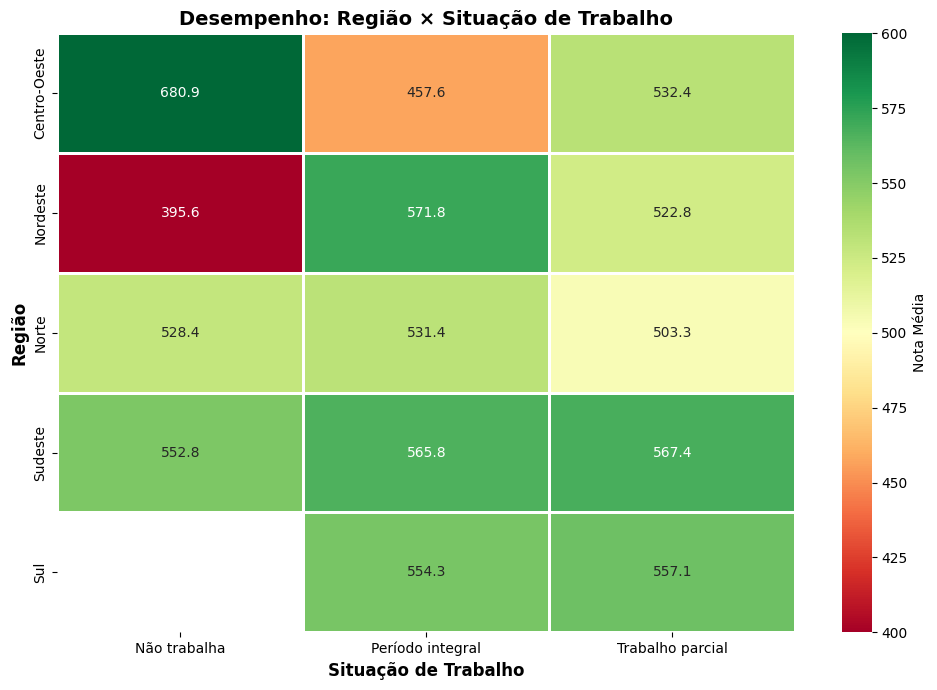


 IMPACTO DO TRABALHO POR REGIÃO (Gap):
REGIAO_NOME_PROVA
Centro-Oeste    223.25
Norte            -3.05
Sudeste         -13.02
Nordeste       -176.20
Sul                NaN
dtype: float64


In [4]:
if 'REGIAO_NOME_PROVA' in df.columns:
    pivot_regiao = df.pivot_table(
        values='NOTA_MEDIA_5',
        index='REGIAO_NOME_PROVA',
        columns='CATEGORIA_TRABALHO',
        aggfunc='mean'
    )
    
    print("\n NOTA MÉDIA: REGIÃO × TRABALHO")
    print(pivot_regiao.round(2))
    
    # Heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(pivot_regiao, annot=True, fmt='.1f', cmap='RdYlGn',
               vmin=400, vmax=600, cbar_kws={'label': 'Nota Média'},
               linewidths=2, linecolor='white')
    plt.title('Desempenho: Região × Situação de Trabalho', fontsize=14, fontweight='bold')
    plt.xlabel('Situação de Trabalho', fontsize=12, fontweight='bold')
    plt.ylabel('Região', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '11_intersecao_regiao_trabalho.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Identificar região mais afetada
    if 'Não trabalha' in pivot_regiao.columns and 'Período integral' in pivot_regiao.columns:
        gaps_regiao = pivot_regiao['Não trabalha'] - pivot_regiao['Período integral']
        print("\n IMPACTO DO TRABALHO POR REGIÃO (Gap):")
        print(gaps_regiao.sort_values(ascending=False).round(2))

## 4⃣ Tripla Interseção: Renda × Escola × Trabalho


 SEGMENTOS: RENDA × ESCOLA × TRABALHO
RENDA_CAT ESCOLA_LABEL  TRABALHA       mean  count TRABALHA_LABEL
    Baixa      Privada         1 518.405450    400       Trabalha
    Baixa      Pública         1 514.474325    289       Trabalha


/tmp/ipykernel_13413/1859537026.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segmentos = df.groupby(['RENDA_CAT', 'ESCOLA_LABEL', 'TRABALHA'])['NOTA_MEDIA_5'].agg(


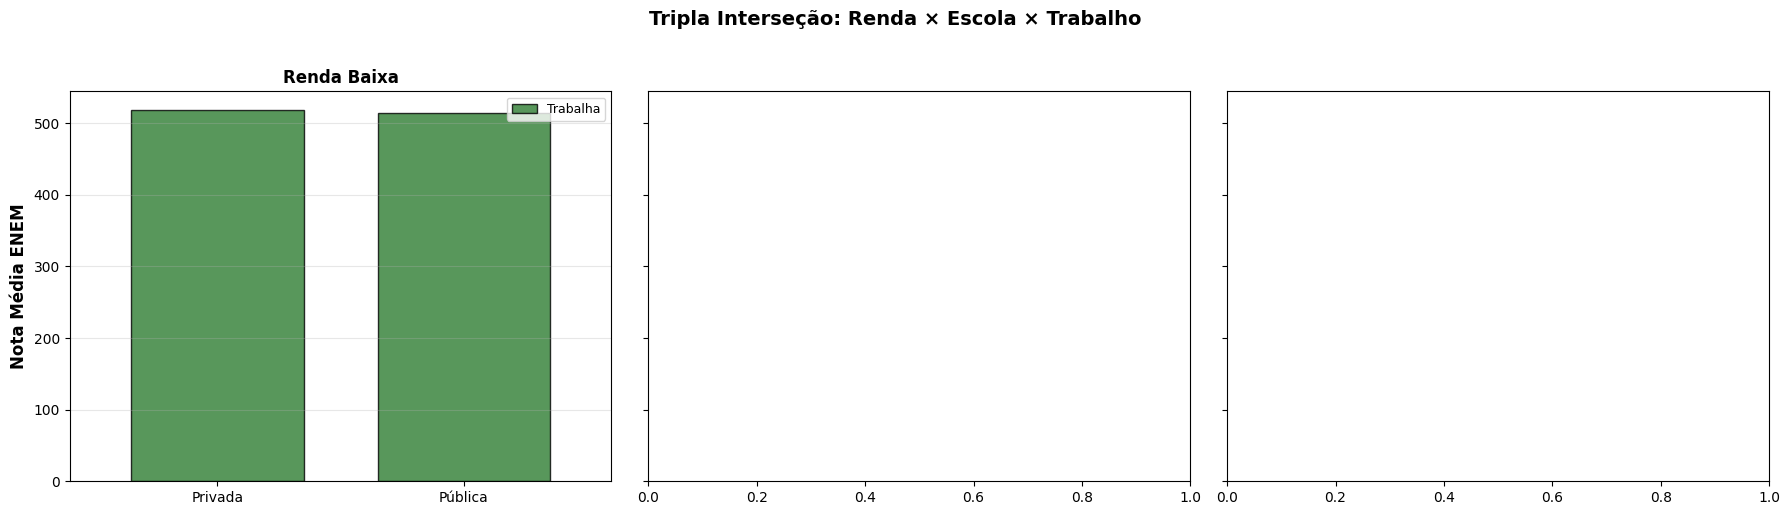

In [5]:
if all(col in df.columns for col in ['RENDA_CAT', 'ESCOLA_LABEL', 'TRABALHA']):
    # Criar segmentos
    segmentos = df.groupby(['RENDA_CAT', 'ESCOLA_LABEL', 'TRABALHA'])['NOTA_MEDIA_5'].agg(
        ['mean', 'count']
    ).reset_index()
    
    segmentos['TRABALHA_LABEL'] = segmentos['TRABALHA'].map({0: 'Não trabalha', 1: 'Trabalha'})
    
    # Filtrar segmentos com dados suficientes
    segmentos = segmentos[segmentos['count'] > 100]
    
    print("\n SEGMENTOS: RENDA × ESCOLA × TRABALHO")
    print(segmentos.sort_values('mean', ascending=False).to_string(index=False))
    
    # Visualização facetada
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    
    for idx, renda in enumerate(['Baixa', 'Média', 'Alta']):
        dados_renda = segmentos[segmentos['RENDA_CAT'] == renda]
        
        pivot = dados_renda.pivot(index='ESCOLA_LABEL', 
                                  columns='TRABALHA_LABEL', 
                                  values='mean')
        
        if not pivot.empty:
            pivot.plot(kind='bar', ax=axes[idx], color=['#2E7D32', '#EF5350'],
                      alpha=0.8, edgecolor='black', width=0.7)
            axes[idx].set_title(f'Renda {renda}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('')
            axes[idx].set_xticklabels(pivot.index, rotation=0)
            axes[idx].grid(axis='y', alpha=0.3)
            axes[idx].legend(title='', fontsize=9)
    
    axes[0].set_ylabel('Nota Média ENEM', fontsize=12, fontweight='bold')
    fig.suptitle('Tripla Interseção: Renda × Escola × Trabalho', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '12_tripla_intersecao.png', dpi=300, bbox_inches='tight')
    plt.show()

##  Conclusões das Interseções

### Principais Achados:
1. **Renda:** O impacto do trabalho varia conforme a renda familiar
2. **Escola:** Diferenças entre pública e privada se mantêm em todos os grupos
3. **Região:** Desigualdades regionais são amplificadas pelo trabalho
4. **Tripla Interseção:** Grupos vulneráveis sofrem efeito acumulado

 **Próximo:** `06_modelagem_preditiva_trabalho.ipynb` - Regressão e ML